In [1]:
from langchain_openai import ChatOpenAI

import os
from dotenv import load_dotenv

load_dotenv()
if os.environ.get("OPENAI_API_KEY"):
    print("Open AI API Key is set.")
else:
    raise ValueError("Open AI API Key is not set")

Open AI API Key is set.


In [4]:
from langchain_core.messages import HumanMessage
llm = ChatOpenAI(model = "gpt-5-nano")
llm.invoke([HumanMessage(content="What is the capital of France?")])

AIMessage(content='Paris. If you’d like more info about Paris (population, landmarks, history), I can share some.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 13, 'total_tokens': 108, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DNDayxk8E6ZrzXdVZaayDNmrgb6QF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d240a-b599-74b2-b6ea-c755fec7b216-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 95, 'total_tokens': 108, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [ ]:
# Flow Humans message to AI message
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, List, Annotated
from operator import add

# 2 Ways to define the schema of the graph
class graph_schema(TypedDict):
    message_manual: List

    # Using reducer
    message_auto: Annotated[List, add]

In [16]:
#Node 1
from langchain_core.messages import AIMessage

def create_post(state: graph_schema) -> graph_schema:
    message_manual = state["message_manual"]
    response_manual = llm.invoke(message_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    state["message_manual"].append(response_manual_ai)
    # state["message_manual"] = response_manual + [response_manual_ai]

    message_auto = state["message_auto"]
    response_auto = llm.invoke(message_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state["message_auto"] = [response_auto_ai]  # Bcoz we are reducing it 

    return state

#Node 2
def curate_post(state: graph_schema) -> graph_schema:
    message_manual = state["message_manual"]
    response_manual = llm.invoke(message_manual).content
    response_manual_ai = AIMessage(content=response_manual)
    state["message_manual"].append(response_manual_ai)

    # Using reducers
    message_auto = state["message_auto"]
    response_auto = llm.invoke(message_auto).content
    response_auto_ai = AIMessage(content=response_auto)
    state["message_auto"] = [response_auto_ai]  # Bcoz we are reducing it 

    return state

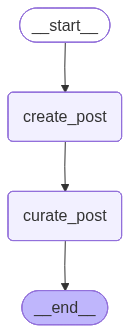

In [17]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Add nodes to the graph
graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

# Define the edges between the nodes
graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

msg_graph = graph.compile()

from IPython.display import Image
Image(msg_graph.get_graph().draw_mermaid_png())

In [19]:
msg_graph.invoke(
    {
        "message_manual" :[HumanMessage(content="The importance of Data Privacy in teh digital era.")],
        "message_auto" : [HumanMessage(content="The importance of Data Privacy in teh digital era.")]
    }
)

{'message_manual': [HumanMessage(content='The importance of Data Privacy in teh digital era.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Data privacy in the digital era refers to the right and ability of individuals to control how their personal information is collected, stored, used, and shared as we interact online and through connected devices. It’s become a central issue because so much of our lives now generates data that can reveal sensitive details about us.\n\nWhy data privacy matters\n- Autonomy and dignity: You should decide who gets your information and for what purposes, not third parties who collect data without your explicit consent.\n- Protection from harm: Personal data can be misused for identity theft, fraud, targeted scams, discrimination, or reputational damage.\n- Trust and safety: When services respect privacy, people are more willing to engage openly, share truthful information, and participate in digital ecosystems.\n- Innovation depends 